# Combined Dataset Analysis

## 1. Setup & Data Loading <a id="setup"></a>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# For preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# For statistics
from scipy import stats
from scipy.stats import chi2_contingency, normaltest

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10


In [2]:
# Load the pre-combined dataset (without course column)
dataset_file = "/content/uci_combined_students.csv"
df = pd.read_csv(dataset_file)

df.head(5)

# Remove course column if it exists
if 'course' in df.columns:
    df = df.drop('course', axis=1)
    print("✅ Course column removed from dataset")

print("="*80)
print("UNIFIED DATASET LOADED SUCCESSFULLY")
print("="*80)
print(f"Dataset file: {dataset_file}")
print(f"Total Students: {len(df):,}")
print(f"Total Features: {len(df.columns)}")


✅ Course column removed from dataset
UNIFIED DATASET LOADED SUCCESSFULLY
Dataset file: /content/uci_combined_students.csv
Total Students: 1,044
Total Features: 33


In [9]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

## 2. Exploratory Data Analysis (EDA)

In [3]:
### 2.1 Dataset Overview

print("="*80)
print("DATASET STRUCTURE")
print("="*80)
print(f"\nShape: {df.shape}")
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\n{'='*80}")
print("DATA TYPES")
print("="*80)
print(df.dtypes)
print(f"\n{'='*80}")
print("FIRST 10 ROWS")
print("="*80)
display(df.head(10))
print(f"\n{'='*80}")
print("LAST 5 ROWS")
print("="*80)
display(df.tail())

DATASET STRUCTURE

Shape: (1044, 33)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

DATA TYPES
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,reputation,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,2,0,no,no,no,no,yes,yes,yes,no,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,2,2,0,yes,yes,no,no,yes,yes,no,no,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,home,mother,1,2,0,no,yes,yes,no,yes,yes,yes,no,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,5,1,1,1,5,0,14,15,15



LAST 5 ROWS


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
1039,MS,F,19,R,GT3,T,2,3,services,other,course,mother,1,3,1,no,no,no,yes,no,yes,yes,no,5,4,2,1,2,5,4,10,11,10
1040,MS,F,18,U,LE3,T,3,1,teacher,services,course,mother,1,2,0,no,yes,no,no,yes,yes,yes,no,4,3,4,1,1,1,4,15,15,16
1041,MS,F,18,U,GT3,T,1,1,other,other,course,mother,2,2,0,no,no,no,yes,yes,yes,no,no,1,1,1,1,1,5,6,11,12,9
1042,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,6,10,10,10
1043,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,4,10,11,11


### 2.1 Data Dictionary

**UCI Student Performance Dataset - Complete Variable Descriptions**

| Variable | Type | Category | Description | Values/Range |
|----------|------|----------|-------------|--------------|
| **school** | Binary | Demographic | Student's school | GP=Gabriel Pereira, MS=Mousinho da Silveira |
| **sex** | Binary | Demographic | Student's sex | F=Female, M=Male |
| **age** | Numeric | Demographic | Student's age | 15-22 years |
| **address** | Binary | Demographic | Home address type | U=Urban, R=Rural |
| **famsize** | Binary | Family | Family size | LE3=≤3 members, GT3=>3 members |
| **Pstatus** | Binary | Family | Parent's cohabitation status | T=Living together, A=Apart |
| **Medu** | Ordinal | Family | Mother's education level | 0=None, 1=Primary(4th), 2=5th-9th, 3=Secondary, 4=Higher |
| **Fedu** | Ordinal | Family | Father's education level | 0=None, 1=Primary(4th), 2=5th-9th, 3=Secondary, 4=Higher |
| **Mjob** | Categorical | Family | Mother's occupation | teacher, health, services, at_home, other |
| **Fjob** | Categorical | Family | Father's occupation | teacher, health, services, at_home, other |
| **reason** | Categorical | School | Reason for school choice | home, reputation, course, other |
| **guardian** | Categorical | Family | Student's guardian | mother, father, other |
| **traveltime** | Ordinal | School | Home to school travel time | 1=<15min, 2=15-30min, 3=30-60min, 4=>1hr |
| **studytime** | Ordinal | School | Weekly study time | 1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs |
| **failures** | Numeric | School | Past class failures | 0-4 (capped at 4) |
| **schoolsup** | Binary | Support | Extra educational support | yes, no |
| **famsup** | Binary | Support | Family educational support | yes, no |
| **paid** | Binary | Support | Extra paid classes | yes, no |
| **activities** | Binary | Social | Extracurricular activities | yes, no |
| **nursery** | Binary | Social | Attended nursery school | yes, no |
| **higher** | Binary | Social | Wants higher education | yes, no |
| **internet** | Binary | Social | Internet access at home | yes, no |
| **romantic** | Binary | Social | In romantic relationship | yes, no |
| **famrel** | Ordinal | Family | Quality of family relationships | 1=Very bad, 5=Excellent |
| **freetime** | Ordinal | Social | Free time after school | 1=Very low, 5=Very high |
| **goout** | Ordinal | Social | Going out with friends | 1=Very low, 5=Very high |
| **Dalc** | Ordinal | Health | Workday alcohol consumption | 1=Very low, 5=Very high |
| **Walc** | Ordinal | Health | Weekend alcohol consumption | 1=Very low, 5=Very high |
| **health** | Ordinal | Health | Current health status | 1=Very bad, 5=Very good |
| **absences** | Numeric | School | Number of school absences | 0-93 |
| **G1** | Numeric | Target | First period grade | 0-20 |
| **G2** | Numeric | Target | Second period grade | 0-20 |
| **G3** | Numeric | Target | **Final grade (PRIMARY TARGET)** | 0-20 |

**Note**: All features have no missing values in the original dataset.

In [5]:
### 2.3 Feature Categorization

# Categorize features by type
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("="*80)
print("FEATURE CATEGORIZATION")
print("="*80)
print(f"\n📊 Numeric Features ({len(numeric_features)}):")
print(numeric_features)
print(f"\n📋 Categorical Features ({len(categorical_features)}):")
print(categorical_features)


FEATURE CATEGORIZATION

📊 Numeric Features (16):
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

📋 Categorical Features (17):
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [6]:
# Semantic grouping based on UCI dataset documentation
demographic_features = ['age', 'sex', 'address']
family_features = ['famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'guardian', 'famrel']
school_features = ['school', 'reason', 'traveltime', 'studytime', 'failures', 'schoolsup', 'paid', 'absences']
social_features = ['activities', 'nursery', 'higher', 'internet', 'romantic', 'freetime', 'goout']
health_behavior_features = ['Dalc', 'Walc', 'health']
support_features = ['famsup', 'schoolsup', 'paid']
grade_features = ['G1', 'G2', 'G3']

print(f"\n{'='*80}")
print("SEMANTIC GROUPING (UCI Dataset Structure)")
print("="*80)
print(f"\n👤 Demographic ({len(demographic_features)}):")
print(f"   {demographic_features}")
print(f"   Description: Student's basic demographic information (age, sex, location)")

print(f"\n👨‍👩‍👧‍👦 Family-Related ({len(family_features)}):")
print(f"   {family_features}")
print(f"   Description: Family background, parents' education/occupation, relationships")

print(f"\n🎓 School-Related ({len(school_features)}):")
print(f"   {school_features}")
print(f"   Description: School choice, study habits, support services, attendance")

print(f"\n🎯 Social & Lifestyle ({len(social_features)}):")
print(f"   {social_features}")
print(f"   Description: Extracurricular activities, social life, future aspirations")

print(f"\n💊 Health & Behavior ({len(health_behavior_features)}):")
print(f"   {health_behavior_features}")
print(f"   Description: Alcohol consumption (weekday/weekend), health status")

print(f"\n🎖️ Educational Support ({len(support_features)}):")
print(f"   {support_features}")
print(f"   Description: Family support, school support, extra paid classes")

print(f"\n📈 Academic Performance ({len(grade_features)}):")
print(f"   {grade_features}")
print(f"   Description: Grades for 1st period (G1), 2nd period (G2), Final grade (G3)")
print(f"   Note: G3 is the primary target variable (0-20 scale)")


SEMANTIC GROUPING (UCI Dataset Structure)

👤 Demographic (3):
   ['age', 'sex', 'address']
   Description: Student's basic demographic information (age, sex, location)

👨‍👩‍👧‍👦 Family-Related (8):
   ['famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'guardian', 'famrel']
   Description: Family background, parents' education/occupation, relationships

🎓 School-Related (8):
   ['school', 'reason', 'traveltime', 'studytime', 'failures', 'schoolsup', 'paid', 'absences']
   Description: School choice, study habits, support services, attendance

🎯 Social & Lifestyle (7):
   ['activities', 'nursery', 'higher', 'internet', 'romantic', 'freetime', 'goout']
   Description: Extracurricular activities, social life, future aspirations

💊 Health & Behavior (3):
   ['Dalc', 'Walc', 'health']
   Description: Alcohol consumption (weekday/weekend), health status

🎖️ Educational Support (3):
   ['famsup', 'schoolsup', 'paid']
   Description: Family support, school support, extra paid classes

📈 Aca

In [7]:
### 2.4 Statistical Summary

print("="*80)
print("NUMERIC FEATURES - STATISTICAL SUMMARY")
print("="*80)
display(df[numeric_features].describe().T)

print(f"\n{'='*80}")
print("CATEGORICAL FEATURES - VALUE COUNTS")
print("="*80)
for col in categorical_features:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts())
    print(f"  Unique values: {df[col].nunique()}")

NUMERIC FEATURES - STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,1044.000,16.726,1.240,15.000,16.000,17.000,18.000,22.000
Medu,1044.000,2.603,1.125,0.000,2.000,3.000,4.000,4.000
Fedu,1044.000,2.388,1.100,0.000,1.000,2.000,3.000,4.000
traveltime,1044.000,1.523,0.732,1.000,1.000,1.000,2.000,4.000
studytime,1044.000,1.970,0.834,1.000,1.000,2.000,2.000,4.000
failures,1044.000,0.264,0.656,0.000,0.000,0.000,0.000,3.000
famrel,1044.000,3.936,0.933,1.000,4.000,4.000,5.000,5.000
freetime,1044.000,3.201,1.032,1.000,3.000,3.000,4.000,5.000
goout,1044.000,3.156,1.153,1.000,2.000,3.000,4.000,5.000
Dalc,1044.000,1.494,0.912,1.000,1.000,1.000,2.000,5.000



CATEGORICAL FEATURES - VALUE COUNTS

SCHOOL:
school
GP    772
MS    272
Name: count, dtype: int64
  Unique values: 2

SEX:
sex
F    591
M    453
Name: count, dtype: int64
  Unique values: 2

ADDRESS:
address
U    759
R    285
Name: count, dtype: int64
  Unique values: 2

FAMSIZE:
famsize
GT3    738
LE3    306
Name: count, dtype: int64
  Unique values: 2

PSTATUS:
Pstatus
T    923
A    121
Name: count, dtype: int64
  Unique values: 2

MJOB:
Mjob
other       399
services    239
at_home     194
teacher     130
health       82
Name: count, dtype: int64
  Unique values: 5

FJOB:
Fjob
other       584
services    292
teacher      65
at_home      62
health       41
Name: count, dtype: int64
  Unique values: 5

REASON:
reason
course        430
home          258
reputation    248
other         108
Name: count, dtype: int64
  Unique values: 4

GUARDIAN:
guardian
mother    728
father    243
other      73
Name: count, dtype: int64
  Unique values: 3

SCHOOLSUP:
schoolsup
no     925
yes    119
Name

## 3. Data Quality Assessment

In [8]:
### 3.1 Missing Values Analysis

print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
    'Data_Type': df.dtypes
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    display(missing_data)

    # Visualize missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_data['Column'], missing_data['Missing_Percentage'], color='coral')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Feature')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ NO MISSING VALUES FOUND IN THE DATASET!")

MISSING VALUES ANALYSIS

✅ NO MISSING VALUES FOUND IN THE DATASET!


In [9]:
### 3.2 Duplicate Records

print("="*80)
print("DUPLICATE RECORDS ANALYSIS")
print("="*80)

duplicates = df.duplicated().sum()
print(f"\nTotal duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"Percentage of duplicates: {(duplicates/len(df))*100:.2f}%")
    print("\nSample duplicate rows:")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("✅ No duplicate records found!")

DUPLICATE RECORDS ANALYSIS

Total duplicate rows: 0
✅ No duplicate records found!


OUTLIER DETECTION USING IQR METHOD


,Feature,Outlier_Count,Outlier_Percentage,Lower_Bound,Upper_Bound
5,failures,183,17.529,0.000,0.000
6,famrel,77,7.375,2.500,6.500
7,freetime,64,6.130,1.500,5.500
4,studytime,62,5.939,-0.500,3.500
12,absences,54,5.172,-9.000,15.000
15,G3,54,5.172,4.000,20.000
9,Dalc,52,4.981,-0.500,3.500
3,traveltime,24,2.299,-0.500,3.500
14,G2,20,1.916,3.000,19.000
0,age,2,0.192,13.000,21.000


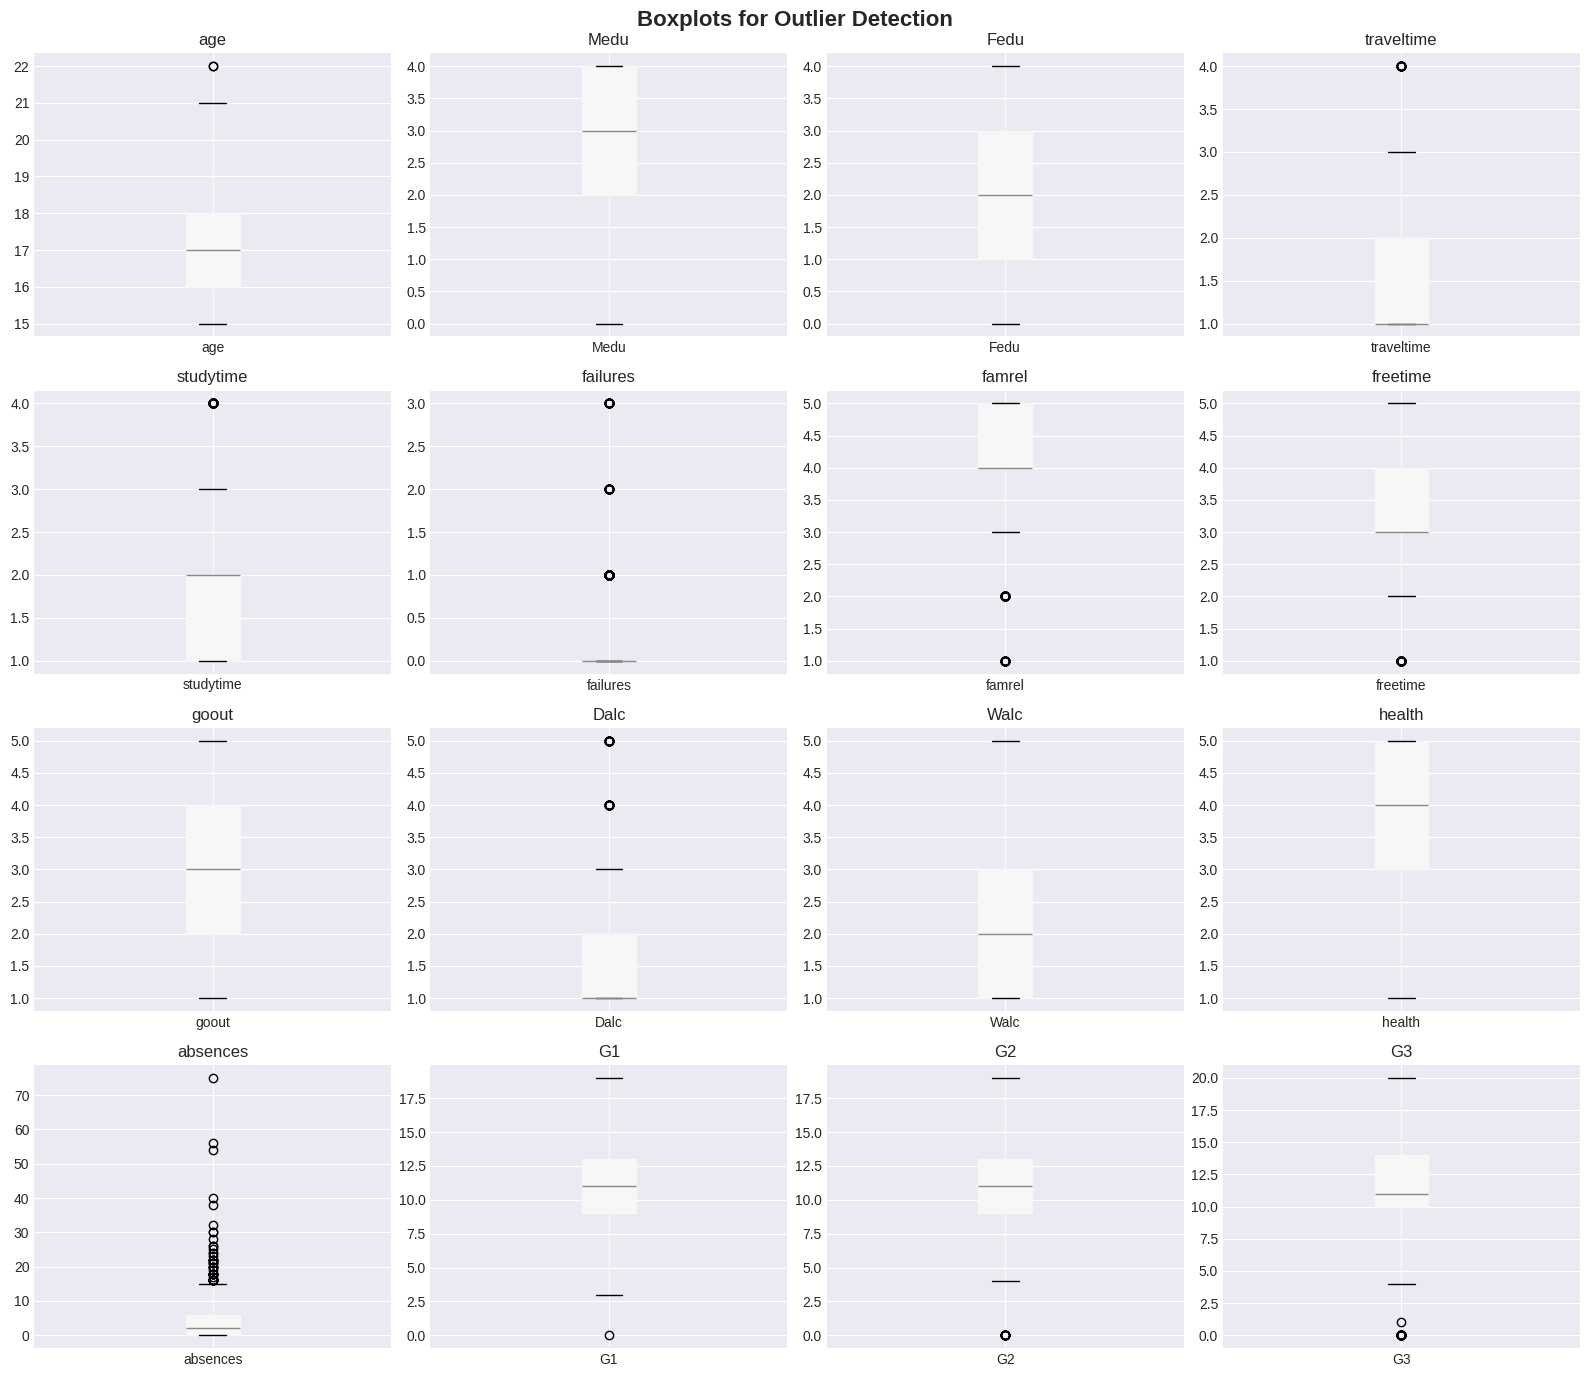

In [10]:
### 3.3 Outlier Detection (Numeric Features)

print("="*80)
print("OUTLIER DETECTION USING IQR METHOD")
print("="*80)

outlier_summary = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100

    outlier_summary.append({
        'Feature': col,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': outlier_pct,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Count', ascending=False)
display(outlier_df)

# Visualize outliers using boxplots
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
fig.suptitle('Boxplots for Outlier Detection', fontsize=16, fontweight='bold')
axes = axes.ravel()

for idx, col in enumerate(numeric_features[:16]):
    df.boxplot(column=col, ax=axes[idx], patch_artist=True)
    axes[idx].set_title(col)
    axes[idx].set_ylabel('')

plt.tight_layout()
plt.show()

## 4. Preprocessing Pipeline

In [11]:
### 4.1 Encode Categorical Variables

# Create a copy for preprocessing
df_processed = df.copy()

print("="*80)
print("ENCODING CATEGORICAL VARIABLES")
print("="*80)

# Initialize label encoders
label_encoders = {}

# Encode all categorical variables
for col in categorical_features:
    le = LabelEncoder()
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

    print(f"\n{col}:")
    print(f"  Original values: {df_processed[col].unique()}")
    print(f"  Encoded values: {df_processed[col + '_encoded'].unique()}")
    print(f"  Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\n✅ Encoded {len(categorical_features)} categorical features")
print(f"New dataset shape: {df_processed.shape}")

ENCODING CATEGORICAL VARIABLES

school:
  Original values: ['GP' 'MS']
  Encoded values: [0 1]
  Mapping: {'GP': np.int64(0), 'MS': np.int64(1)}

sex:
  Original values: ['F' 'M']
  Encoded values: [0 1]
  Mapping: {'F': np.int64(0), 'M': np.int64(1)}

address:
  Original values: ['U' 'R']
  Encoded values: [1 0]
  Mapping: {'R': np.int64(0), 'U': np.int64(1)}

famsize:
  Original values: ['GT3' 'LE3']
  Encoded values: [0 1]
  Mapping: {'GT3': np.int64(0), 'LE3': np.int64(1)}

Pstatus:
  Original values: ['A' 'T']
  Encoded values: [0 1]
  Mapping: {'A': np.int64(0), 'T': np.int64(1)}

Mjob:
  Original values: ['at_home' 'health' 'other' 'services' 'teacher']
  Encoded values: [0 1 2 3 4]
  Mapping: {'at_home': np.int64(0), 'health': np.int64(1), 'other': np.int64(2), 'services': np.int64(3), 'teacher': np.int64(4)}

Fjob:
  Original values: ['teacher' 'other' 'services' 'health' 'at_home']
  Encoded values: [4 2 3 1 0]
  Mapping: {'at_home': np.int64(0), 'health': np.int64(1), 'other

In [12]:
### 4.2 Feature Scaling (Normalization & Standardization)

# Select numeric columns for scaling (exclude target variable G3)
features_to_scale = [col for col in numeric_features if col not in ['G1', 'G2', 'G3']]

# MinMax Normalization (0-1)
scaler_minmax = MinMaxScaler()
df_processed[[col + '_normalized' for col in features_to_scale]] = scaler_minmax.fit_transform(df_processed[features_to_scale])

# Z-score Standardization
scaler_standard = StandardScaler()
df_processed[[col + '_standardized' for col in features_to_scale]] = scaler_standard.fit_transform(df_processed[features_to_scale])

print("="*80)
print("FEATURE SCALING COMPLETED")
print("="*80)
print(f"✅ MinMax Normalization: {len(features_to_scale)} features scaled to [0,1]")
print(f"✅ Z-score Standardization: {len(features_to_scale)} features standardized (mean=0, std=1)")
print(f"\nScaled features: {features_to_scale}")
print(f"\nNew dataset shape: {df_processed.shape}")

FEATURE SCALING COMPLETED
✅ MinMax Normalization: 13 features scaled to [0,1]
✅ Z-score Standardization: 13 features standardized (mean=0, std=1)

Scaled features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

New dataset shape: (1044, 76)


## 5. Feature Engineering

In [13]:
### 5.1 Create Derived Features

print("="*80)
print("FEATURE ENGINEERING")
print("="*80)

# 1. Parent education average
df_processed['parent_edu_avg'] = (df_processed['Medu'] + df_processed['Fedu']) / 2

# 2. Total alcohol consumption
df_processed['total_alcohol'] = df_processed['Dalc'] + df_processed['Walc']

# 3. Social activity score (goout + freetime)
df_processed['social_score'] = df_processed['goout'] + df_processed['freetime']

# 4. Study-to-goout ratio
df_processed['study_goout_ratio'] = df_processed['studytime'] / (df_processed['goout'] + 1)  # +1 to avoid division by zero

# 5. Grade progression (G2-G1 and G3-G2)
df_processed['grade_progress_1to2'] = df_processed['G2'] - df_processed['G1']
df_processed['grade_progress_2to3'] = df_processed['G3'] - df_processed['G2']
df_processed['grade_progress_total'] = df_processed['G3'] - df_processed['G1']

# 6. Binary flags
df_processed['has_failures'] = (df_processed['failures'] > 0).astype(int)
df_processed['high_absences'] = (df_processed['absences'] > df_processed['absences'].median()).astype(int)
df_processed['passed'] = (df_processed['G3'] >= 10).astype(int)  # Pass/Fail (10 is passing grade)

# 7. Performance category
def categorize_performance(grade):
    if grade >= 16:
        return 'Excellent'
    elif grade >= 14:
        return 'Good'
    elif grade >= 10:
        return 'Satisfactory'
    else:
        return 'Needs Improvement'

df_processed['performance_category'] = df_processed['G3'].apply(categorize_performance)

print("\n✅ Created Derived Features:")
print("  - parent_edu_avg: Average of mother's and father's education")
print("  - total_alcohol: Sum of weekday and weekend alcohol consumption")
print("  - social_score: Combined social activity metric")
print("  - study_goout_ratio: Balance between study and social time")
print("  - grade_progress_*: Grade improvement tracking")
print("  - has_failures: Binary flag for past failures")
print("  - high_absences: Binary flag for above-median absences")
print("  - passed: Binary pass/fail indicator")
print("  - performance_category: 4-level performance classification")

print(f"\nNew dataset shape: {df_processed.shape}")

FEATURE ENGINEERING

✅ Created Derived Features:
  - parent_edu_avg: Average of mother's and father's education
  - total_alcohol: Sum of weekday and weekend alcohol consumption
  - social_score: Combined social activity metric
  - study_goout_ratio: Balance between study and social time
  - grade_progress_*: Grade improvement tracking
  - has_failures: Binary flag for past failures
  - high_absences: Binary flag for above-median absences
  - passed: Binary pass/fail indicator
  - performance_category: 4-level performance classification

New dataset shape: (1044, 87)


## 6. Correlation Analysis

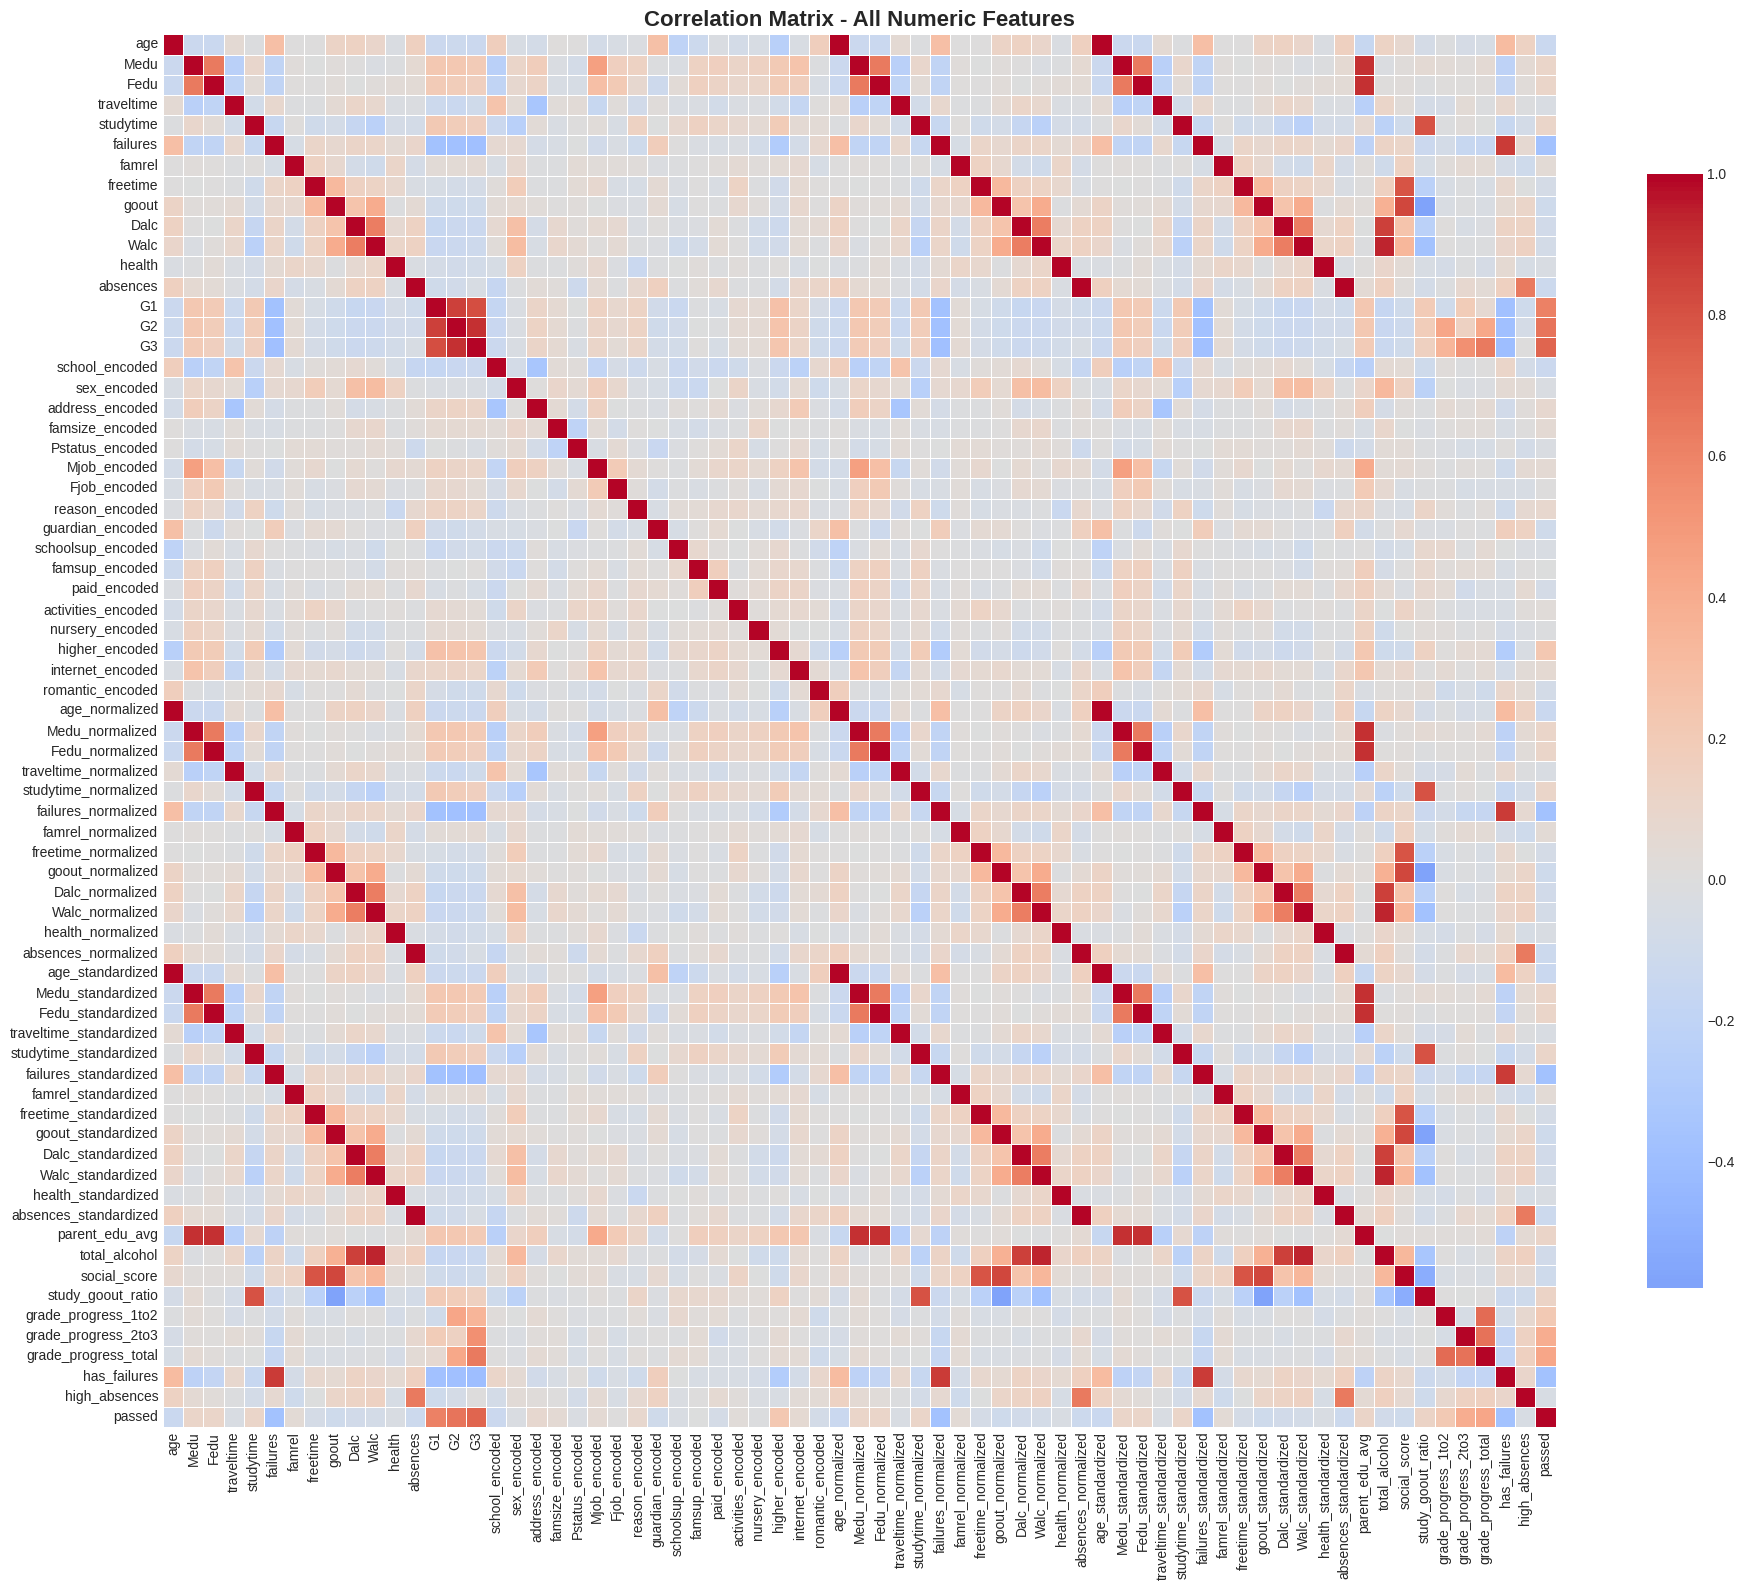

Correlation matrix computed for 69 numeric features


In [14]:
### 6.1 Correlation Matrix - All Numeric Features

# Select all numeric columns (including encoded and engineered features)
all_numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
corr_matrix = df_processed[all_numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*80)
print(f"Correlation matrix computed for {len(all_numeric_cols)} numeric features")
print("="*80)

TOP 15 POSITIVE CORRELATIONS WITH FINAL GRADE (G3)
G3                       1.000
G2                       0.911
G1                       0.809
passed                   0.730
grade_progress_total     0.638
grade_progress_2to3      0.541
grade_progress_1to2      0.342
higher_encoded           0.237
Medu_standardized        0.201
Medu                     0.201
Medu_normalized          0.201
parent_edu_avg           0.200
studytime                0.162
studytime_normalized     0.162
studytime_standardized   0.162
Name: G3, dtype: float64

TOP 10 NEGATIVE CORRELATIONS WITH FINAL GRADE (G3)
age_normalized          -0.125
school_encoded          -0.127
Dalc_standardized       -0.130
Dalc_normalized         -0.130
Dalc                    -0.130
total_alcohol           -0.134
failures_standardized   -0.383
failures                -0.383
failures_normalized     -0.383
has_failures            -0.400
Name: G3, dtype: float64


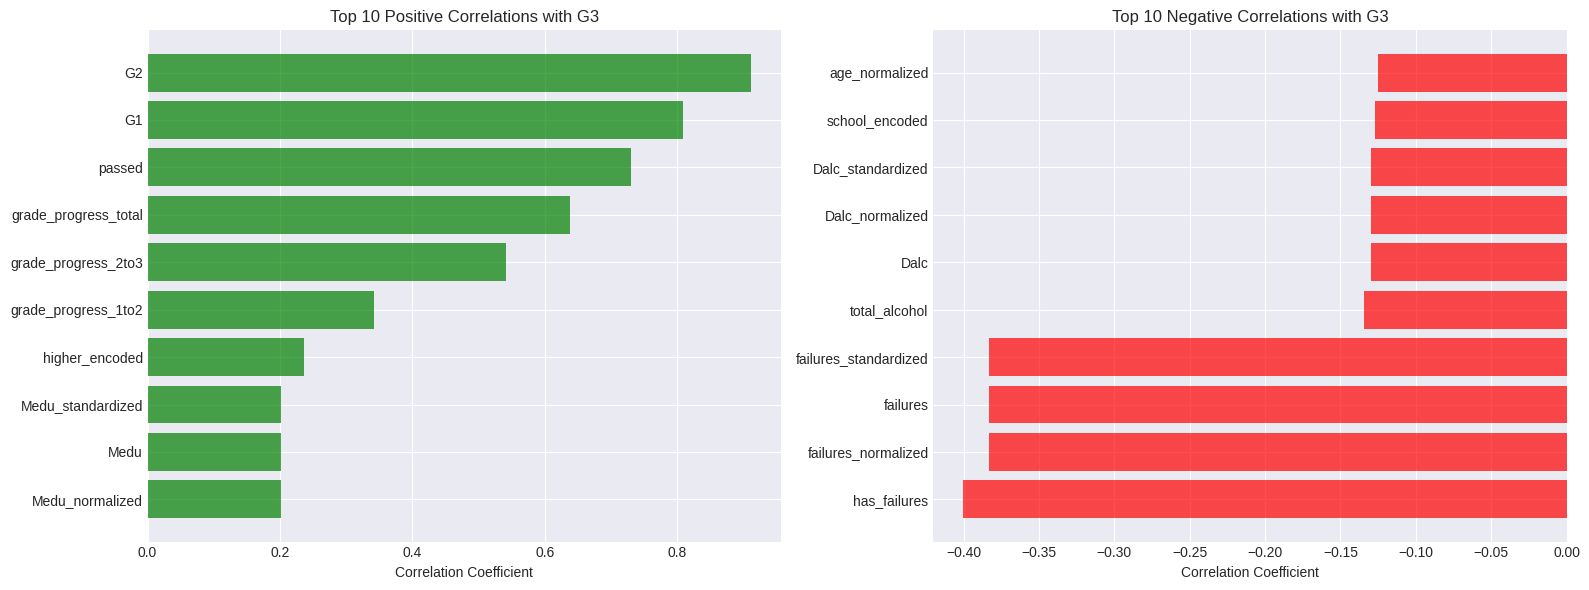

In [15]:
### 6.2 Top Correlations with Final Grade (G3)

# Get correlations with G3
g3_correlations = corr_matrix['G3'].sort_values(ascending=False)

# Top positive correlations
top_positive = g3_correlations.head(15)
# Top negative correlations
top_negative = g3_correlations.tail(10)

print("="*80)
print("TOP 15 POSITIVE CORRELATIONS WITH FINAL GRADE (G3)")
print("="*80)
print(top_positive)

print(f"\n{'='*80}")
print("TOP 10 NEGATIVE CORRELATIONS WITH FINAL GRADE (G3)")
print("="*80)
print(top_negative)

# Visualize top correlations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Positive correlations
top_positive_filtered = top_positive.drop('G3').head(10)
ax1.barh(range(len(top_positive_filtered)), top_positive_filtered.values, color='green', alpha=0.7)
ax1.set_yticks(range(len(top_positive_filtered)))
ax1.set_yticklabels(top_positive_filtered.index)
ax1.set_xlabel('Correlation Coefficient')
ax1.set_title('Top 10 Positive Correlations with G3')
ax1.invert_yaxis()

# Negative correlations
ax2.barh(range(len(top_negative)), top_negative.values, color='red', alpha=0.7)
ax2.set_yticks(range(len(top_negative)))
ax2.set_yticklabels(top_negative.index)
ax2.set_xlabel('Correlation Coefficient')
ax2.set_title('Top 10 Negative Correlations with G3')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [16]:
### 6.3 Feature Correlation Clusters

# Find highly correlated feature pairs (excluding self-correlation)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:  # Threshold for high correlation
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print("="*80)
    print("HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7)")
    print("="*80)
    display(high_corr_df.head(20))
    print(f"\nTotal highly correlated pairs: {len(high_corr_df)}")
else:
    print("No highly correlated feature pairs found (threshold: 0.7)")

HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7)


,Feature_1,Feature_2,Correlation
44,studytime_normalized,studytime_standardized,1.000
25,Dalc,Dalc_standardized,1.000
3,Medu,Medu_standardized,1.000
39,Medu_normalized,Medu_standardized,1.000
53,Dalc_normalized,Dalc_standardized,1.000
10,studytime,studytime_normalized,1.000
9,traveltime,traveltime_standardized,1.000
22,goout,goout_standardized,1.000
51,goout_normalized,goout_standardized,1.000
11,studytime,studytime_standardized,1.000



Total highly correlated pairs: 68


## 7. Distribution Analysis

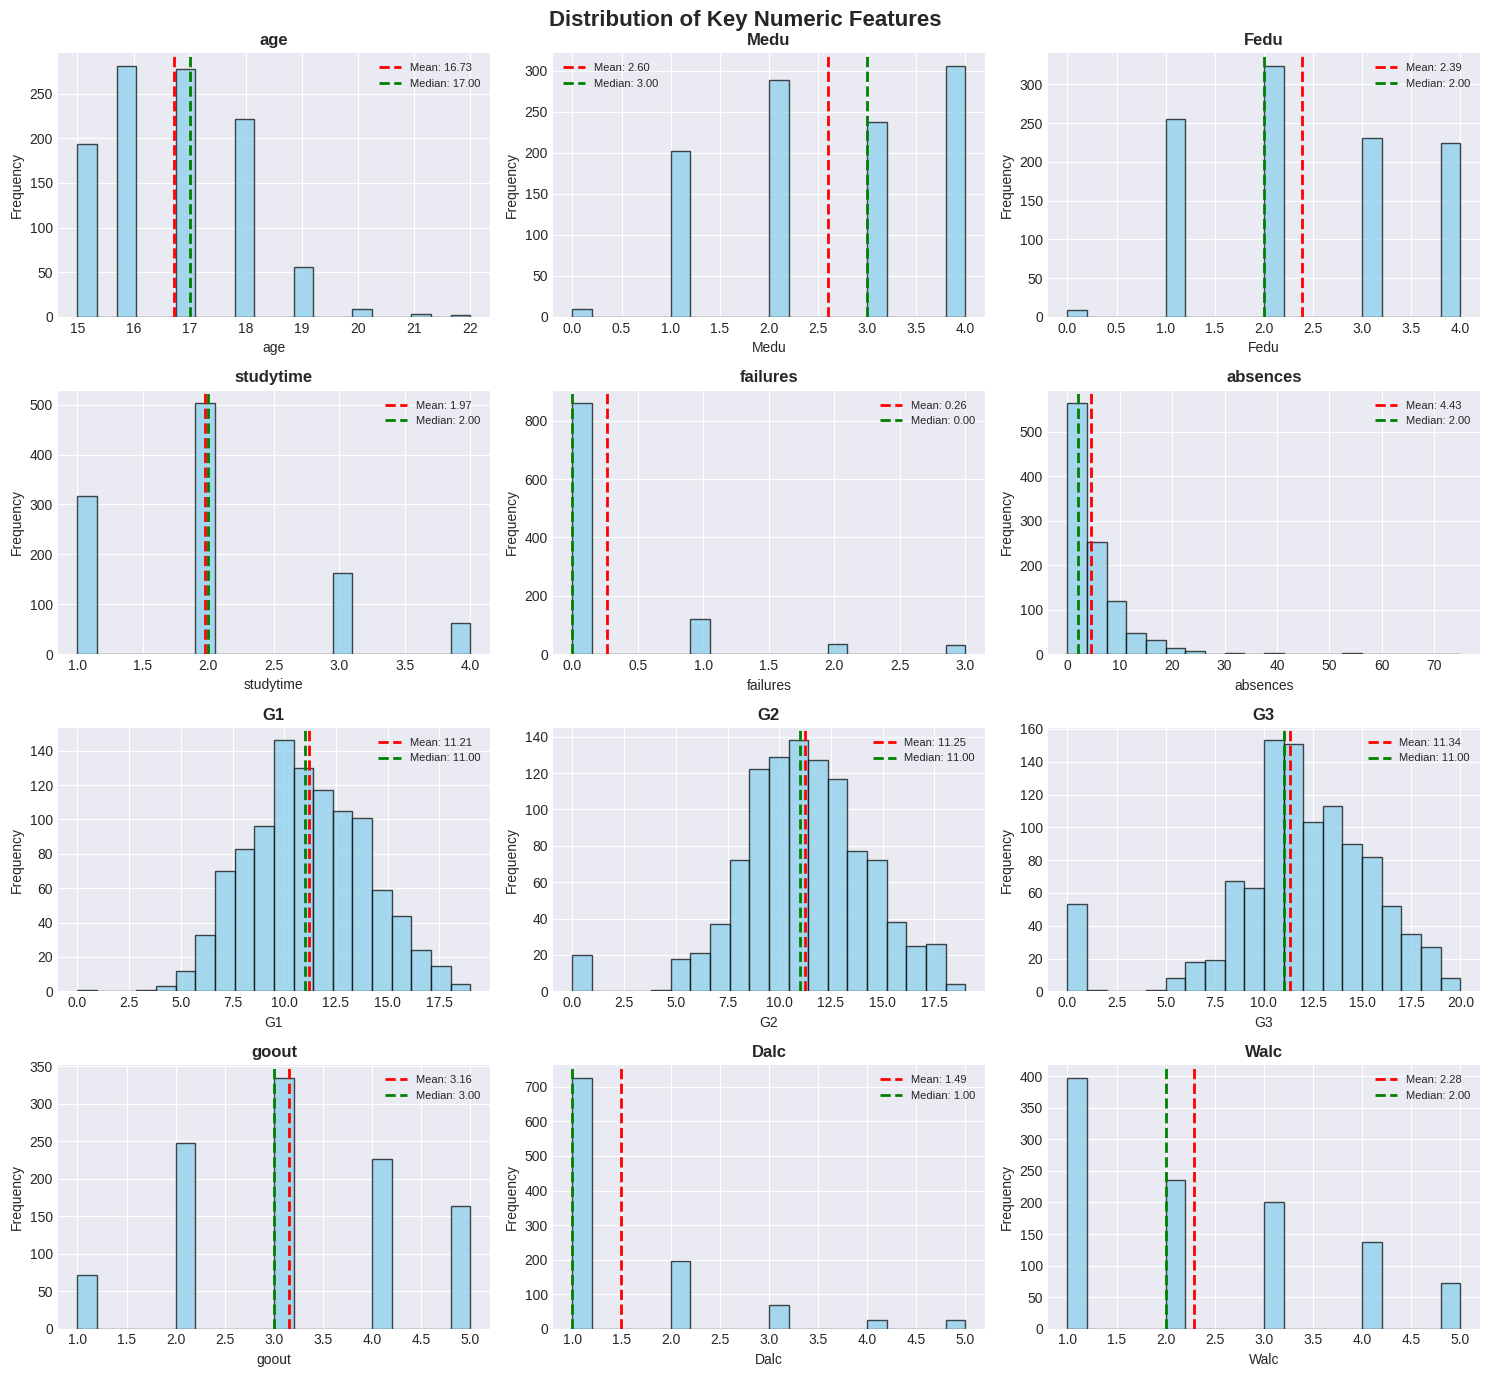

In [17]:
### 7.1 Numeric Feature Distributions

# Plot distributions for key numeric features
key_features = ['age', 'Medu', 'Fedu', 'studytime', 'failures', 'absences',
                'G1', 'G2', 'G3', 'goout', 'Dalc', 'Walc']

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
fig.suptitle('Distribution of Key Numeric Features', fontsize=16, fontweight='bold')
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    axes[idx].hist(df_processed[feature], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(feature, fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df_processed[feature].mean(), color='red', linestyle='--',
                     linewidth=2, label=f'Mean: {df_processed[feature].mean():.2f}')
    axes[idx].axvline(df_processed[feature].median(), color='green', linestyle='--',
                     linewidth=2, label=f'Median: {df_processed[feature].median():.2f}')
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

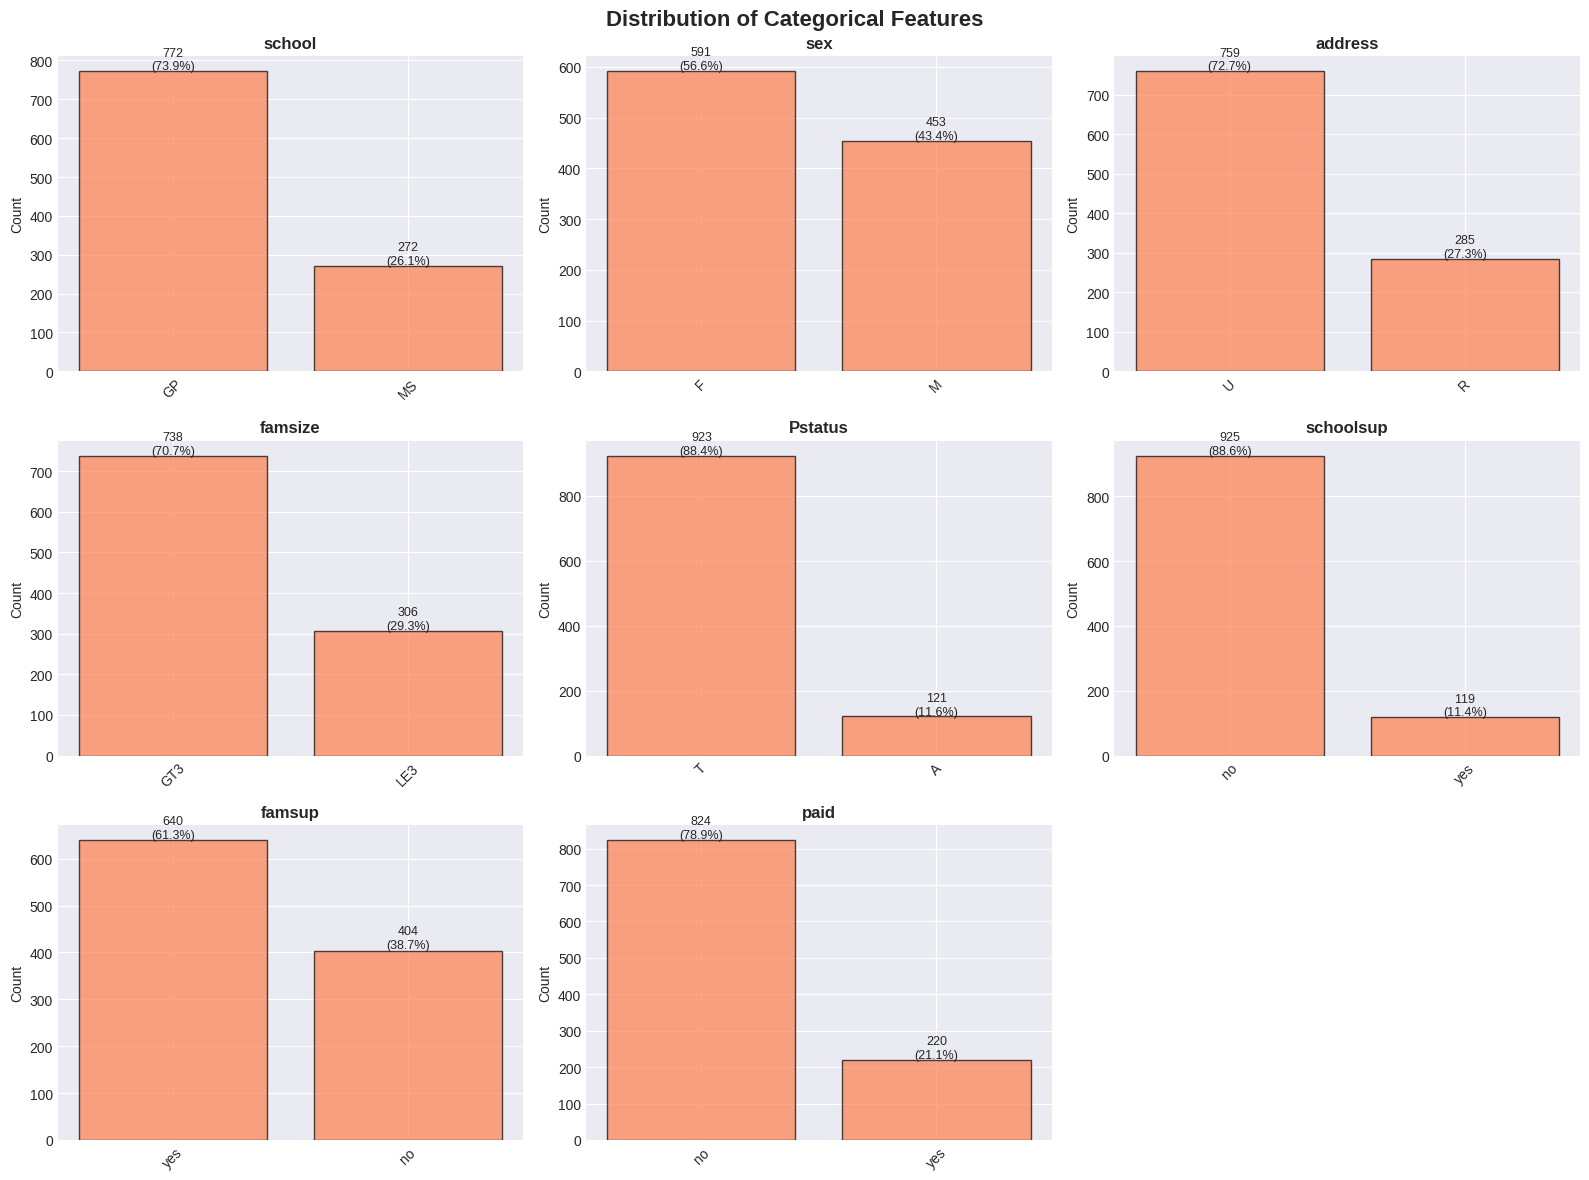

In [18]:
### 7.2 Categorical Feature Distributions

# Plot distributions for categorical features
cat_features_to_plot = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold')
axes = axes.ravel()

for idx, feature in enumerate(cat_features_to_plot):
    if idx < len(axes):
        value_counts = df_processed[feature].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='coral', edgecolor='black', alpha=0.7)
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45)
        axes[idx].set_title(feature, fontweight='bold')
        axes[idx].set_ylabel('Count')

        # Add percentage labels
        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)',
                          ha='center', fontsize=9)

# Hide unused subplots
for idx in range(len(cat_features_to_plot), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 8. Relationship Visualizations

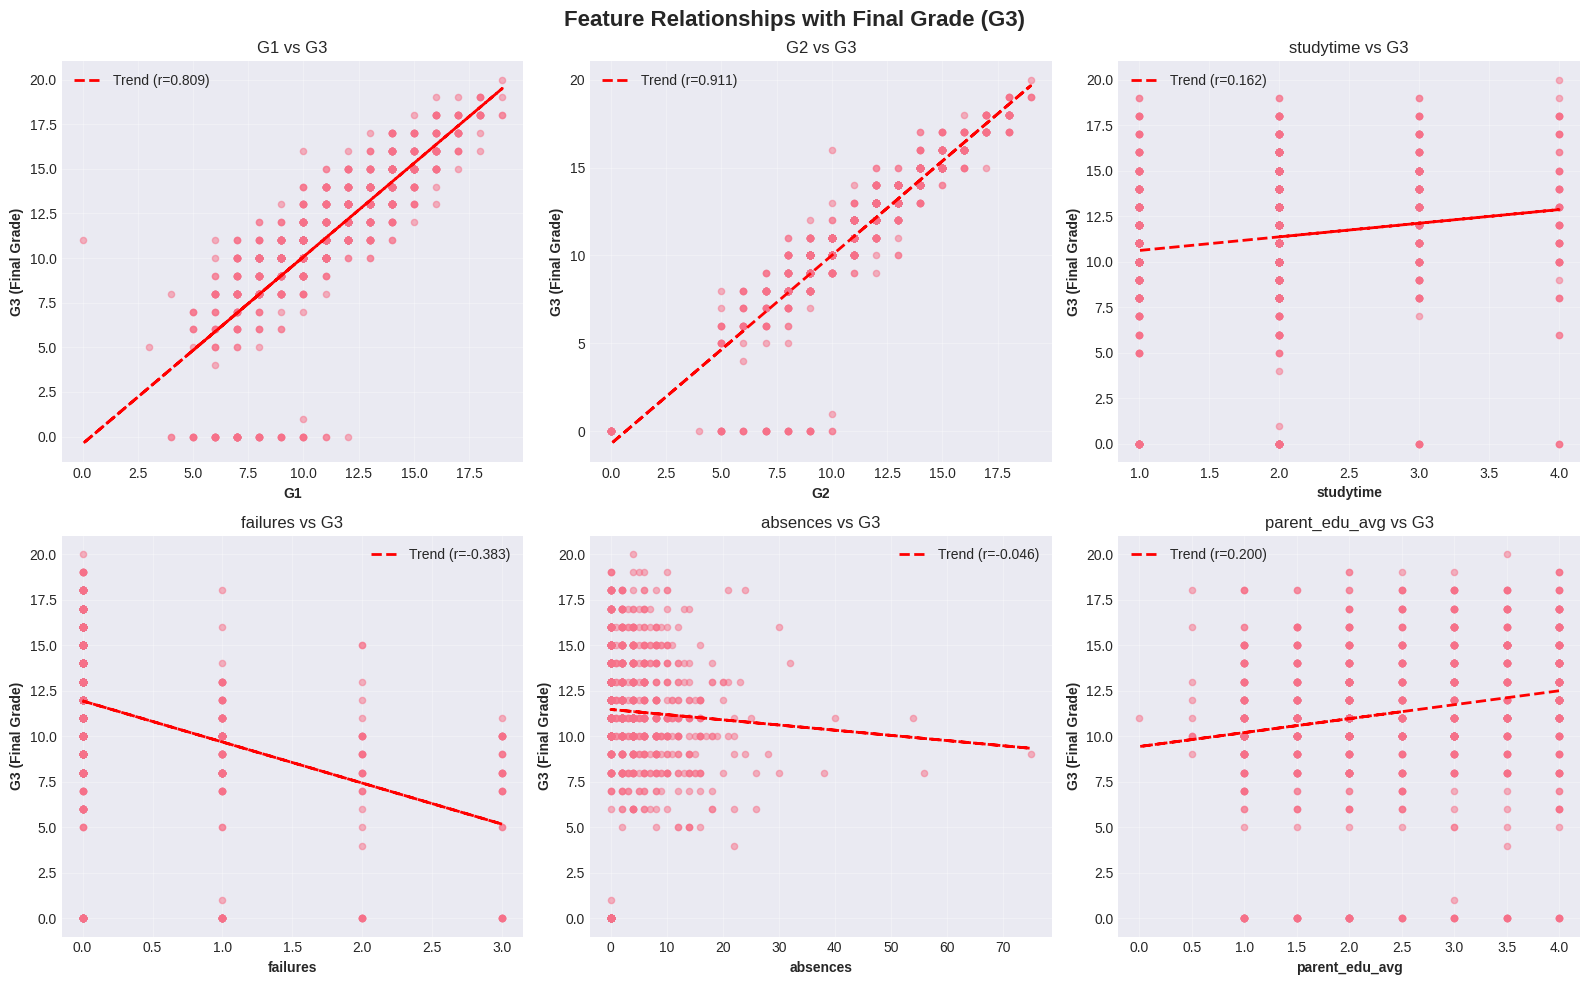

In [19]:
### 8.1 Scatter Plots - Feature Relationships with G3

# Key features to plot against G3
features_vs_g3 = ['G1', 'G2', 'studytime', 'failures', 'absences', 'parent_edu_avg']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Relationships with Final Grade (G3)', fontsize=16, fontweight='bold')
axes = axes.ravel()

for idx, feature in enumerate(features_vs_g3):
    axes[idx].scatter(df_processed[feature], df_processed['G3'], alpha=0.5, s=20)
    axes[idx].set_xlabel(feature, fontweight='bold')
    axes[idx].set_ylabel('G3 (Final Grade)', fontweight='bold')
    axes[idx].set_title(f'{feature} vs G3')

    # Add trend line
    z = np.polyfit(df_processed[feature], df_processed['G3'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_processed[feature], p(df_processed[feature]), "r--", linewidth=2,
                  label=f'Trend (r={df_processed[feature].corr(df_processed["G3"]):.3f})')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

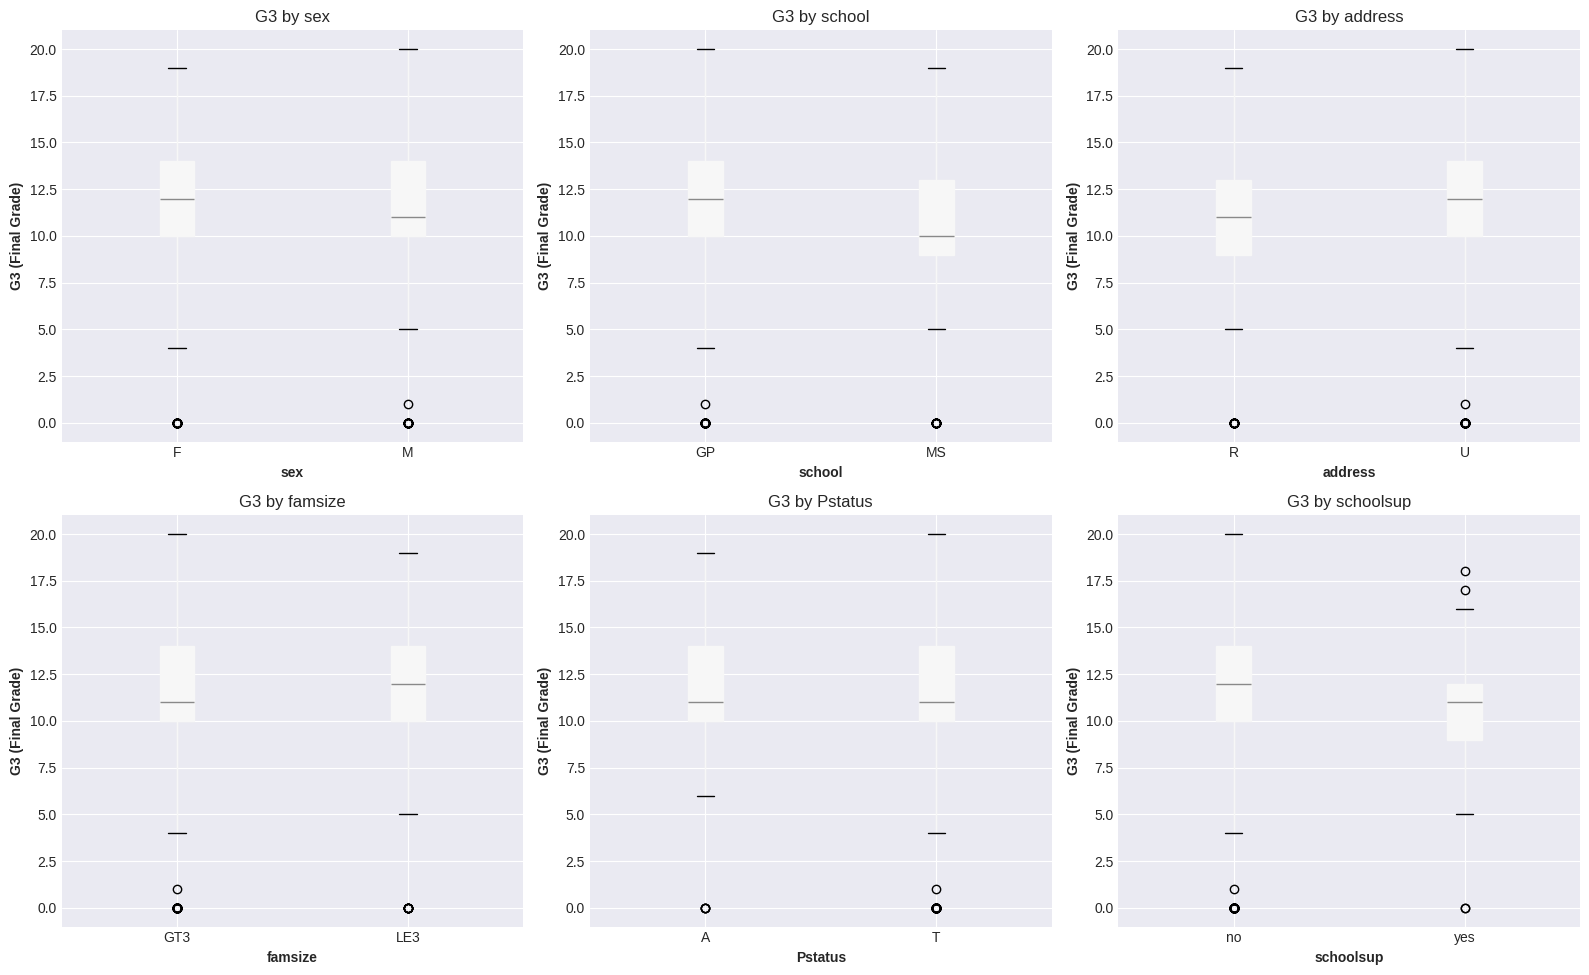

In [20]:
### 8.2 Box Plots - Categorical Features vs G3

# Categorical features to analyze
cat_features_vs_g3 = ['sex', 'school', 'address', 'famsize', 'Pstatus', 'schoolsup']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Final Grade (G3) Distribution by Categorical Features', fontsize=16, fontweight='bold')
axes = axes.ravel()

for idx, feature in enumerate(cat_features_vs_g3):
    df_processed.boxplot(column='G3', by=feature, ax=axes[idx], patch_artist=True)
    axes[idx].set_title(f'G3 by {feature}')
    axes[idx].set_xlabel(feature, fontweight='bold')
    axes[idx].set_ylabel('G3 (Final Grade)', fontweight='bold')
    axes[idx].get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

Generating pair plot for key features (this may take a moment)...


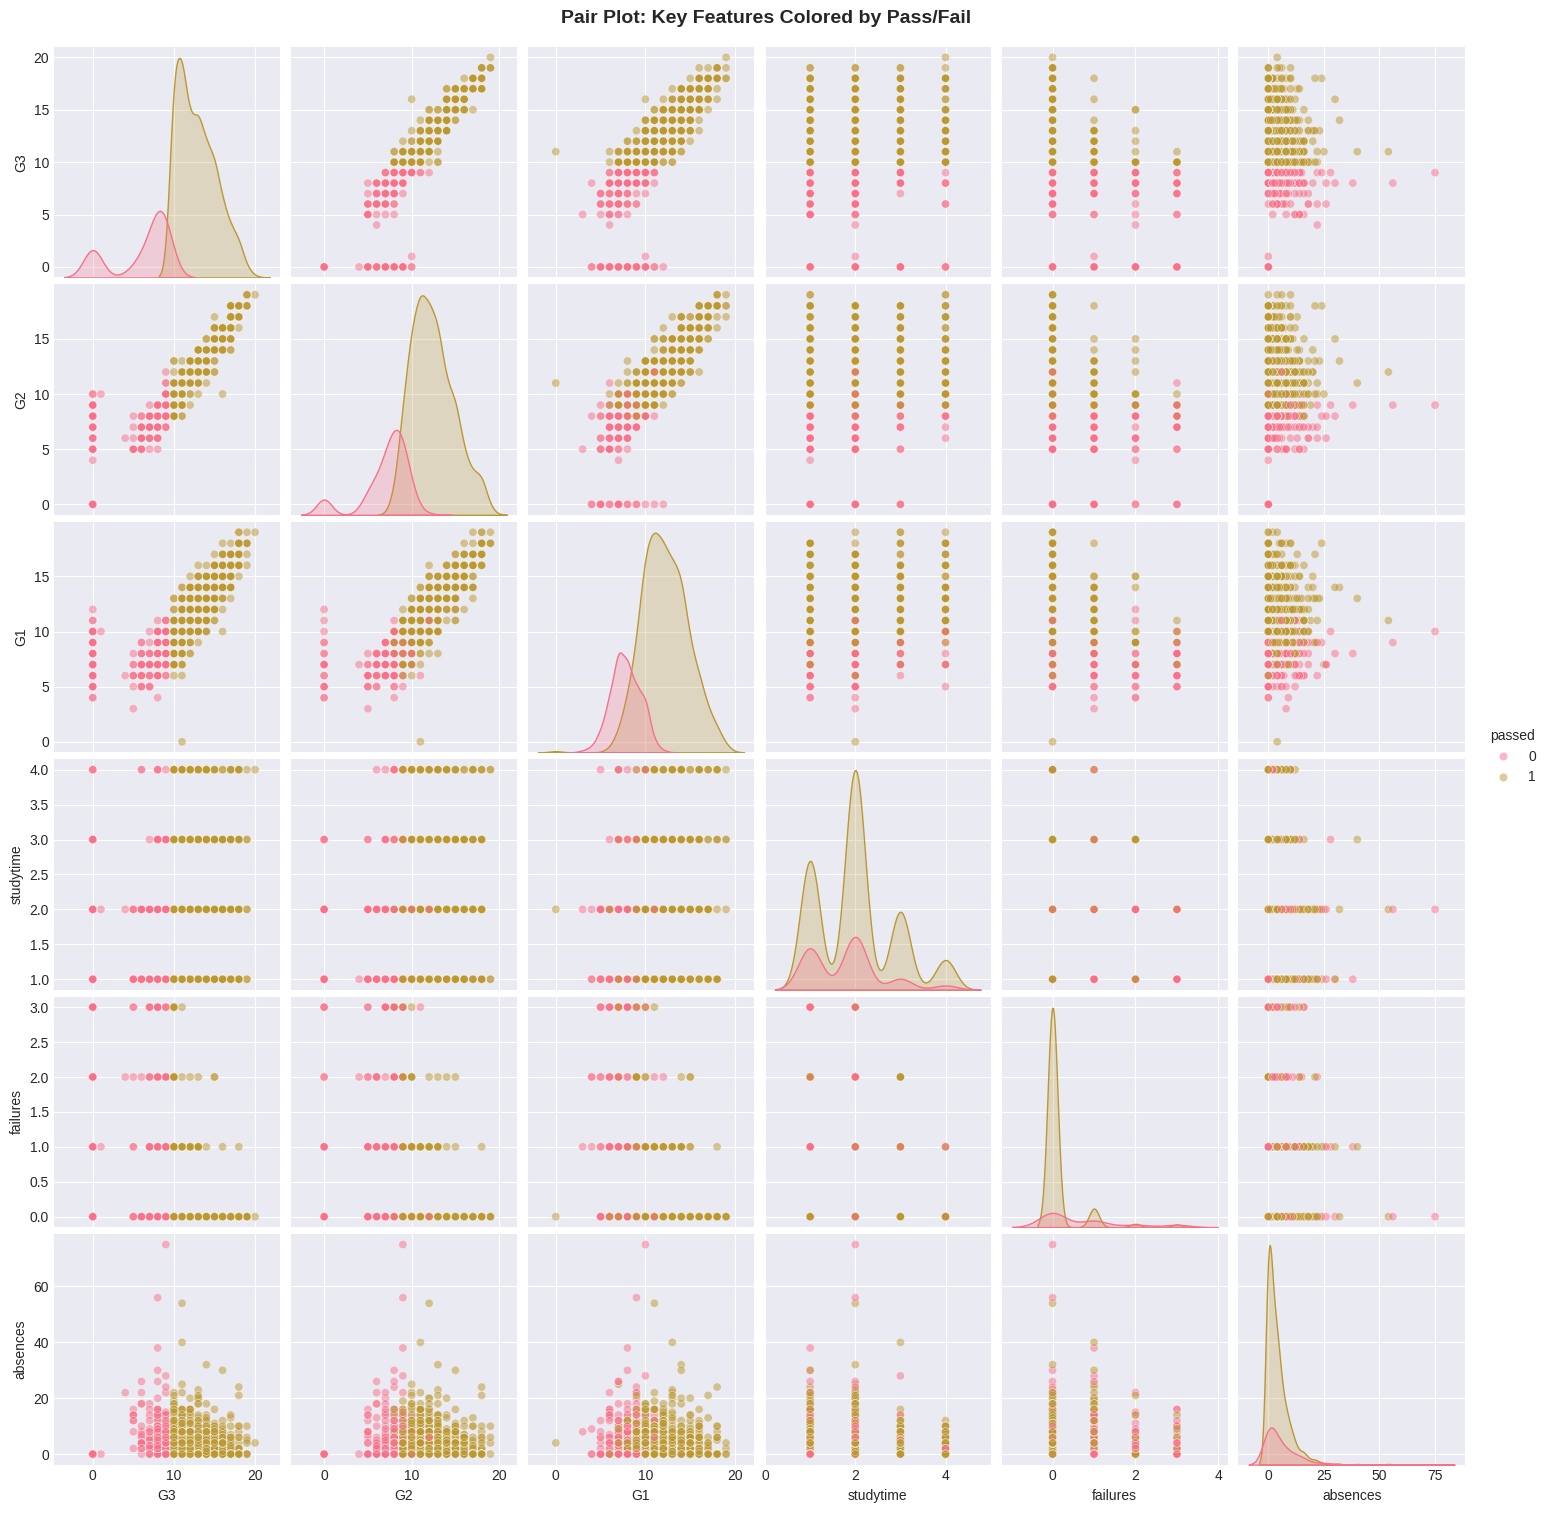

✅ Pair plot completed!


In [21]:
### 8.3 Pair Plot - Key Feature Interactions

# Select key features for pair plot
pairplot_features = ['G3', 'G2', 'G1', 'studytime', 'failures', 'absences', 'passed']

print("Generating pair plot for key features (this may take a moment)...")
sns.pairplot(df_processed[pairplot_features], hue='passed', diag_kind='kde',
             plot_kws={'alpha':0.5}, height=2.5)
plt.suptitle('Pair Plot: Key Features Colored by Pass/Fail', y=1.01, fontsize=14, fontweight='bold')
plt.show()
print("✅ Pair plot completed!")

## 9. Target Variable Analysis

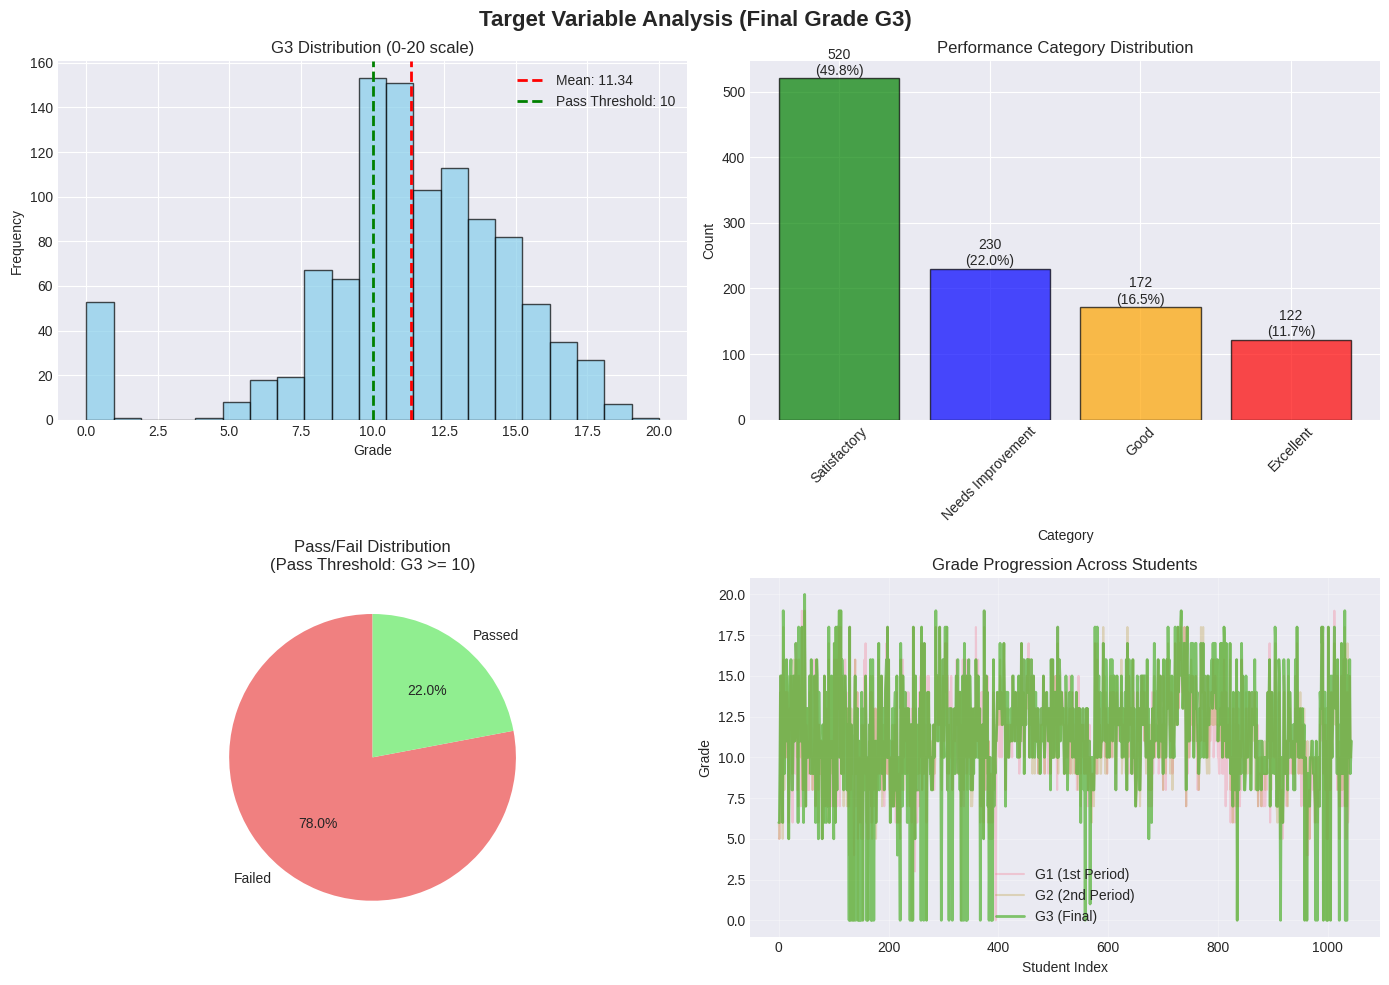

TARGET VARIABLE STATISTICS
Mean G3: 11.34
Median G3: 11.00
Std Dev G3: 3.86
Min G3: 0
Max G3: 20

Pass Rate: 77.97%
Fail Rate: 22.03%


In [22]:
### 9.1 Grade Distribution Analysis

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Target Variable Analysis (Final Grade G3)', fontsize=16, fontweight='bold')

# G3 distribution
axes[0, 0].hist(df_processed['G3'], bins=21, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('G3 Distribution (0-20 scale)')
axes[0, 0].set_xlabel('Grade')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_processed['G3'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_processed["G3"].mean():.2f}')
axes[0, 0].axvline(10, color='green', linestyle='--', linewidth=2, label='Pass Threshold: 10')
axes[0, 0].legend()

# Performance category distribution
perf_counts = df_processed['performance_category'].value_counts()
axes[0, 1].bar(perf_counts.index, perf_counts.values, color=['green', 'blue', 'orange', 'red'], alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Performance Category Distribution')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(perf_counts.values):
    axes[0, 1].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')

# Pass/Fail distribution
pass_counts = df_processed['passed'].value_counts()
axes[1, 0].pie(pass_counts.values, labels=['Failed', 'Passed'], autopct='%1.1f%%',
               colors=['lightcoral', 'lightgreen'], startangle=90)
axes[1, 0].set_title(f'Pass/Fail Distribution\n(Pass Threshold: G3 >= 10)')

# Grade progression
axes[1, 1].plot(df_processed.index, df_processed['G1'], label='G1 (1st Period)', alpha=0.3)
axes[1, 1].plot(df_processed.index, df_processed['G2'], label='G2 (2nd Period)', alpha=0.3)
axes[1, 1].plot(df_processed.index, df_processed['G3'], label='G3 (Final)', alpha=0.7, linewidth=2)
axes[1, 1].set_title('Grade Progression Across Students')
axes[1, 1].set_xlabel('Student Index')
axes[1, 1].set_ylabel('Grade')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*80)
print("TARGET VARIABLE STATISTICS")
print("="*80)
print(f"Mean G3: {df_processed['G3'].mean():.2f}")
print(f"Median G3: {df_processed['G3'].median():.2f}")
print(f"Std Dev G3: {df_processed['G3'].std():.2f}")
print(f"Min G3: {df_processed['G3'].min()}")
print(f"Max G3: {df_processed['G3'].max()}")
print(f"\nPass Rate: {(df_processed['passed'].sum() / len(df_processed)) * 100:.2f}%")
print(f"Fail Rate: {((1-df_processed['passed']).sum() / len(df_processed)) * 100:.2f}%")

# **Data Mining prep**

In [23]:
### 10.1 Prepare Datasets for Different Mining Tasks

print("="*80)
print("PREPARING DATASETS FOR DATA MINING TASKS")
print("="*80)

# 1. Classification Dataset (Predicting G3 or Pass/Fail)
# Use encoded categorical features and numeric features
classification_features = [col for col in df_processed.columns if '_encoded' in col or col in numeric_features]
classification_features = [f for f in classification_features if f not in ['G3', 'G1', 'G2']]  # Exclude target and intermediate grades

X_classification = df_processed[classification_features]
y_classification_regression = df_processed['G3']  # For regression
y_classification_binary = df_processed['passed']  # For binary classification
y_classification_multiclass = df_processed['performance_category']  # For multiclass

print(f"\n📊 CLASSIFICATION DATASET:")
print(f"  Features: {X_classification.shape[1]}")
print(f"  Samples: {X_classification.shape[0]}")
print(f"  Targets available:")
print(f"    - Regression (G3): continuous 0-20")
print(f"    - Binary (passed): 0/1")
print(f"    - Multiclass (performance_category): 4 classes")

# 2. Clustering Dataset (Unsupervised)
# Use standardized numeric features + encoded categoricals
clustering_features = [col for col in df_processed.columns if'_standardized' in col or '_encoded' in col]
X_clustering = df_processed[clustering_features]

print(f"\n🔮 CLUSTERING DATASET:")
print(f"  Features: {X_clustering.shape[1]}")
print(f"  Samples: {X_clustering.shape[0]}")
print(f"  All features standardized for distance-based algorithms")

# 3. Association Rule Mining Dataset
# Create binary/categorical format
arm_features = categorical_features + ['has_failures', 'high_absences', 'passed', 'performance_category']
X_association = df_processed[arm_features]

print(f"\n🔗 ASSOCIATION RULE MINING DATASET:")
print(f"  Features: {X_association.shape[1]}")
print(f"  Samples: {X_association.shape[0]}")
print(f"  All categorical/binary features for pattern discovery")

# Display feature sets
print(f"\n{'='*80}")
print("FEATURE BREAKDOWN")
print("="*80)
print(f"\nClassification Features ({len(classification_features)}):")
print(classification_features[:20], "..." if len(classification_features) > 20 else "")
print(f"\nClustering Features ({len(clustering_features)}):")
print(clustering_features[:20], "..." if len(clustering_features) > 20 else "")
print(f"\nAssociation Features ({len(arm_features)}):")
print(arm_features)

PREPARING DATASETS FOR DATA MINING TASKS

📊 CLASSIFICATION DATASET:
  Features: 30
  Samples: 1044
  Targets available:
    - Regression (G3): continuous 0-20
    - Binary (passed): 0/1
    - Multiclass (performance_category): 4 classes

🔮 CLUSTERING DATASET:
  Features: 30
  Samples: 1044
  All features standardized for distance-based algorithms

🔗 ASSOCIATION RULE MINING DATASET:
  Features: 21
  Samples: 1044
  All categorical/binary features for pattern discovery

FEATURE BREAKDOWN

Classification Features (30):
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'school_encoded', 'sex_encoded', 'address_encoded', 'famsize_encoded', 'Pstatus_encoded', 'Mjob_encoded', 'Fjob_encoded'] ...

Clustering Features (30):
['school_encoded', 'sex_encoded', 'address_encoded', 'famsize_encoded', 'Pstatus_encoded', 'Mjob_encoded', 'Fjob_encoded', 'reason_encoded', 'guardian_encoded', 'schoolsup_encoded', 'famsup_enc

In [24]:
### 10.2 Train-Test Split for Classification

# Split for regression task
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_classification, y_classification_regression, test_size=0.2, random_state=42, stratify=y_classification_binary
)

# Split for binary classification
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_classification, y_classification_binary, test_size=0.2, random_state=42, stratify=y_classification_binary
)

# Split for multiclass classification
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_classification, y_classification_multiclass, test_size=0.2, random_state=42, stratify=y_classification_multiclass
)

print("="*80)
print("TRAIN-TEST SPLITS CREATED")
print("="*80)

print(f"\n📈 REGRESSION (G3 Prediction):")
print(f"  Training set: {X_train_reg.shape[0]} samples")
print(f"  Test set: {X_test_reg.shape[0]} samples")
print(f"  Features: {X_train_reg.shape[1]}")

print(f"\n🎯 BINARY CLASSIFICATION (Pass/Fail):")
print(f"  Training set: {X_train_bin.shape[0]} samples")
print(f"  Test set: {X_test_bin.shape[0]} samples")
print(f"  Class distribution (train):")
print(f"    Passed: {y_train_bin.sum()} ({y_train_bin.sum()/len(y_train_bin)*100:.1f}%)")
print(f"    Failed: {(~y_train_bin.astype(bool)).sum()} ({(~y_train_bin.astype(bool)).sum()/len(y_train_bin)*100:.1f}%)")

print(f"\n🎨 MULTICLASS CLASSIFICATION (Performance Categories):")
print(f"  Training set: {X_train_multi.shape[0]} samples")
print(f"  Test set: {X_test_multi.shape[0]} samples")
print(f"  Class distribution (train):")
print(y_train_multi.value_counts())

print(f"\n✅ All splits maintain stratified class distributions!")

TRAIN-TEST SPLITS CREATED

📈 REGRESSION (G3 Prediction):
  Training set: 835 samples
  Test set: 209 samples
  Features: 30

🎯 BINARY CLASSIFICATION (Pass/Fail):
  Training set: 835 samples
  Test set: 209 samples
  Class distribution (train):
    Passed: 651 (78.0%)
    Failed: 184 (22.0%)

🎨 MULTICLASS CLASSIFICATION (Performance Categories):
  Training set: 835 samples
  Test set: 209 samples
  Class distribution (train):
performance_category
Satisfactory         416
Needs Improvement    184
Good                 137
Excellent             98
Name: count, dtype: int64

✅ All splits maintain stratified class distributions!


## Export

In [26]:
### 11.1 Save Processed Datasets

print("="*80)
print("EXPORTING PROCESSED DATASETS")
print("="*80)

# 1. Full processed dataset with all features
df_processed.to_csv("/content/processed/uci_combined_processed_full.csv", index=False)
print(f"\n✅ Full processed dataset: uci_combined_processed_full.csv")
print(f"   Shape: {df_processed.shape}")

# 2. Classification dataset (ready for ML)
classification_df = df_processed[classification_features + ['G3', 'passed', 'performance_category']]
classification_df.to_csv("/content/processed/uci_classification_ready.csv", index=False)
print(f"\n✅ Classification dataset: uci_classification_ready.csv")
print(f"   Shape: {classification_df.shape}")

# 3. Clustering dataset
clustering_df = df_processed[clustering_features]
clustering_df.to_csv("/content/processed/uci_clustering_ready.csv", index=False)
print(f"\n✅ Clustering dataset: uci_clustering_ready.csv")
print(f"   Shape: {clustering_df.shape}")

# 4. Association rule mining dataset
association_df = df_processed[arm_features]
association_df.to_csv("/content/processed/uci_association_ready.csv", index=False)
print(f"\n✅ Association mining dataset: uci_association_ready.csv")
print(f"   Shape: {association_df.shape}")

# 5. Train-test splits
X_train_bin.to_csv("/content/processed/X_train_classification.csv", index=False)
X_test_bin.to_csv("/content/processed/X_test_classification.csv", index=False)
y_train_bin.to_csv("/content/processed/y_train_classification.csv", index=False, header=True)
y_test_bin.to_csv("/content/processed/y_test_classification.csv", index=False, header=True)
print(f"\n✅ Train-test splits saved (X_train, X_test, y_train, y_test)")

# 6. Feature names and encodings
import json
encoding_info = {
    'label_encoders': {col: dict(zip(le.classes_, le.transform(le.classes_).tolist()))
                      for col, le in label_encoders.items()},
    'classification_features': classification_features,
    'clustering_features': clustering_features,
    'association_features': arm_features
}
with open("/content/processed/encoding_info.json", 'w') as f:
    json.dump(encoding_info, f, indent=2)
print(f"\n✅ Encoding information: encoding_info.json")

print(f"\n{'='*80}")
print(f"All files saved to: /content/processed/")
print("="*80)

EXPORTING PROCESSED DATASETS

✅ Full processed dataset: uci_combined_processed_full.csv
   Shape: (1044, 87)

✅ Classification dataset: uci_classification_ready.csv
   Shape: (1044, 33)

✅ Clustering dataset: uci_clustering_ready.csv
   Shape: (1044, 30)

✅ Association mining dataset: uci_association_ready.csv
   Shape: (1044, 21)

✅ Train-test splits saved (X_train, X_test, y_train, y_test)

✅ Encoding information: encoding_info.json

All files saved to: /content/processed/
